importing libraries

In [3]:

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor


In [4]:
dataset = yf.download("RELIANCE.NS", start="2020-01-01", end="2024-01-01")



[*********************100%***********************]  1 of 1 completed


In [5]:
print(dataset.head())

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2020-01-01  675.324219  683.152914  673.490123  679.081997    14004468
2020-01-02  686.821167  689.348729  676.397839  676.397839    17710316
2020-01-03  687.648804  689.661895  681.318729  685.792252    20984698
2020-01-06  671.700623  683.510705  670.134872  679.976657    24519177
2020-01-07  682.034546  686.463335  677.068889  679.529321    16683622


In [6]:
dataset.isnull().sum()

Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

Print dataframe shape and check NULL values

In [7]:

print("Dataframe shape: ", dataset.shape)
print("NULL value present: ",dataset.isnull().values.any())

Dataframe shape:  (992, 5)
NULL value present:  False


In [8]:
#Checking the top 5 values from the dataset
dataset.head(5)

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,675.324219,683.152914,673.490123,679.081997,14004468
2020-01-02,686.821167,689.348729,676.397839,676.397839,17710316
2020-01-03,687.648804,689.661895,681.318729,685.792252,20984698
2020-01-06,671.700623,683.510705,670.134872,679.976657,24519177
2020-01-07,682.034546,686.463335,677.068889,679.529321,16683622


Set target variable & Selecting features

In [9]:

output_var=pd.DataFrame(dataset['Close'])
features=['Open','High','Low','Volume']

Ploting Close Price History

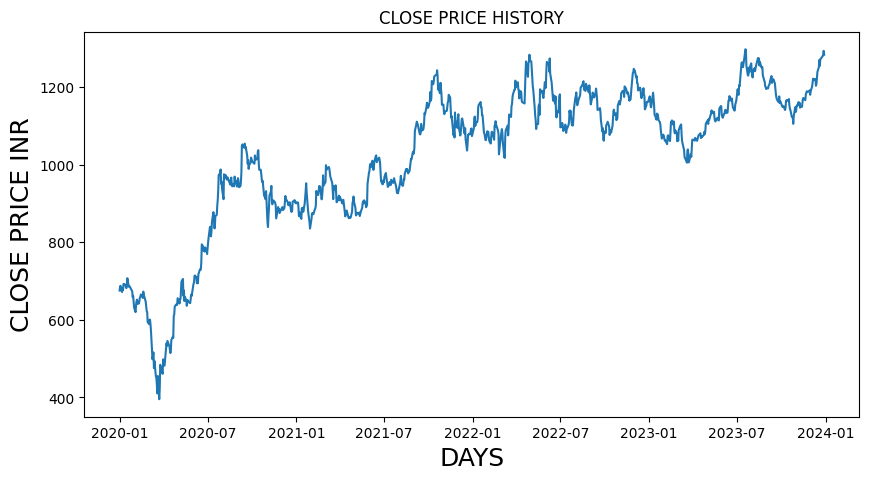

In [10]:


plt.figure(figsize=(10,5))
plt.title('CLOSE PRICE HISTORY')
plt.plot(dataset['Close'])
plt.xlabel('DAYS',fontsize=18)
plt.ylabel('CLOSE PRICE INR',fontsize=18)
plt.show()

Extracting independent and dependent variables

In [11]:

x = dataset.iloc[:, 0:5].values
y = dataset.iloc[:, 4].values

In [12]:
print("x-shape is:",x.shape)
print("y-shape is:",y.shape)

x-shape is: (992, 5)
y-shape is: (992,)


splitting to training set and test set


In [13]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.26,  random_state=0)

In [14]:
print("x-train is:",x_train.shape)
print("y-train is:",y_train.shape)

x-train is: (734, 5)
y-train is: (734,)


In [15]:
print("x-test is:",x_test.shape)
print("y-test is:",y_test.shape)

x-test is: (258, 5)
y-test is: (258,)


Scaling


In [16]:

scaler= MinMaxScaler()
feature_transform = scaler.fit_transform(dataset[features])
feature_transform= pd.DataFrame(columns=features, data=feature_transform, index=dataset.index)
feature_transform.head()

,Open,High,Low,Volume
Date,,,,
2020-01-01,0.302587,0.293783,0.315811,0.087239
2020-01-02,0.299570,0.300834,0.319070,0.113526
2020-01-03,0.310129,0.301190,0.324585,0.136752
2020-01-06,0.303593,0.294190,0.312050,0.161824
2020-01-07,0.303090,0.297550,0.319822,0.106244


Random forest

In [17]:
Random_forest_model = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_split=2, 
                                             min_samples_leaf=1, max_depth=10, bootstrap=True)
Random_forest_model.fit(x_train, y_train)
RF_predict = Random_forest_model.predict(x_test)
print(RF_predict)

[ 6956990.46317222  7297848.64250794 13576585.91574683 12485465.7885759
 19767162.02196667  9948720.85969234  6742552.1940498  27778690.132
 21907283.32053334 13961557.02841905  6941439.02302222  6682687.15778632
 20315704.68740477 28525223.9105     14471280.80922857  9722942.13000238
 12396466.21772301 10646412.07742778 11047804.53830952 18851134.48180952
 36055799.326      12224827.84289286 23706507.076      30505405.957
 34061192.04823333 22710139.28068095  8165872.60326667  8314176.5992
  6992534.69799365 11202904.2086254  14635146.72690159 21876764.41193333
 62316196.86       30535490.1828     19039216.48433333 13196831.31588771
 14834551.32499921 10919216.81908388 16928894.35161905 12656461.10943456
 11786104.83192143 11242097.30771825 11724482.3119619  21950701.90686667
 58591152.29       14239857.07608341 12224919.41499285 17661353.276
 16817735.01985238 53292470.288       6391051.6382619   8624216.33735549
 16274594.97111428 11148830.75550794 11809510.18854127 12799490.4896357

In [18]:

dataset=pd.DataFrame({'Actual':y_test, 'Predicted':RF_predict})
dataset

,Actual,Predicted
0,7007330,6.956990e+06
1,7349922,7.297849e+06
2,13565659,1.357659e+07
3,12496073,1.248547e+07
4,19762858,1.976716e+07
...,...,...
253,9347626,9.344982e+06
254,7576878,7.577371e+06
255,23727866,2.374256e+07
256,35100458,3.512386e+07


In [19]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, RF_predict))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, RF_predict))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, RF_predict)))


Mean Absolute Error: 58279.854940770056
Mean Squared Error: 30780873812.92675
Root Mean Squared Error: 175444.7885031834


In [20]:
RF_result=Random_forest_model.score(x_test,y_test)*100

In [21]:
print("Accuracy: ",round(RF_result,2),'%')

Accuracy:  99.98 %


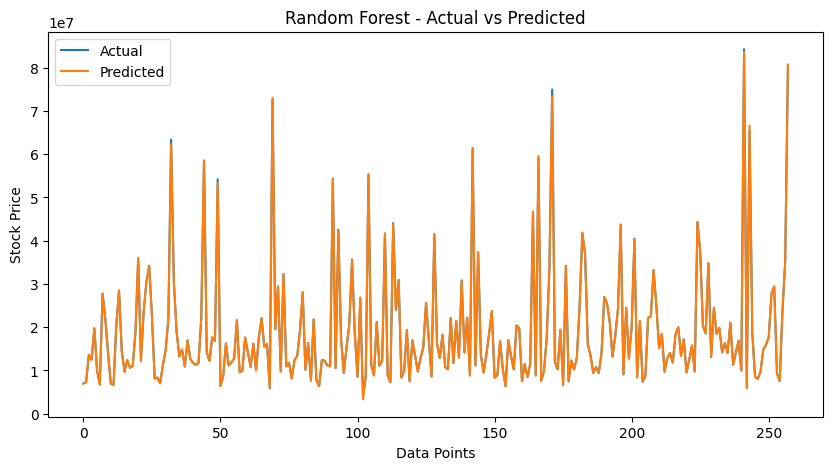

In [22]:


plt.figure(figsize=(10,5))

plt.plot(y_test, label="Actual")        
plt.plot(RF_predict, label="Predicted")

plt.title("Random Forest - Actual vs Predicted")
plt.xlabel("Data Points")
plt.ylabel("Stock Price")

plt.legend()
plt.show()

Decision tree 

In [23]:
DecisionTreemodel = DecisionTreeRegressor( random_state=42, min_samples_split=2, min_samples_leaf=1, max_depth=10)
DecisionTreemodel.fit(x_train, y_train)
DT_predict = DecisionTreemodel.predict(x_test)
print(DT_predict)

[ 6949561.          7310110.         13623855.         12479044.
 19658398.5         9948396.          6774499.33333333 27796343.
 21935444.         13929575.          6949561.          6705291.
 20414228.         28475945.         14447422.          9716161.
 12383195.         10617206.         11036907.66666667 18922799.
 36030932.         12237021.         23804335.         30402290.
 34067814.         22557065.          7972397.          8340678.
  6949561.         11173072.75       14581390.5        21868937.
 62796089.         30497029.         18922799.         13200509.
 14851817.5        10918108.         16876644.         12649971.66666667
 11779819.         11245688.66666667 11720049.         21926473.
 57471248.         14227328.66666667 12237021.         17658543.
 16820604.         53456868.          6413408.          8611849.33333333
 16336573.         11173072.75       11819188.5        12836561.
 21718594.          9527292.          9897780.33333333 17609592.
 14311785

In [24]:
print(DT_predict.shape)

(258,)


In [25]:
dataset=pd.DataFrame({'Actual':y_test, 'Predicted':DT_predict})
dataset

,Actual,Predicted
0,7007330,6949561.0
1,7349922,7310110.0
2,13565659,13623855.0
3,12496073,12479044.0
4,19762858,19658398.5
...,...,...
253,9347626,9333535.0
254,7576878,7580254.0
255,23727866,22885610.0
256,35100458,35189589.0


In [26]:

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, DT_predict))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, DT_predict))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test,DT_predict)))

Mean Absolute Error: 104413.05207641196
Mean Squared Error: 122050630178.07512
Root Mean Squared Error: 349357.4533025954


In [27]:
DT_result=DecisionTreemodel.score(x_test,y_test)*100

In [28]:
print("Accuracy: ",round(DT_result,2),'%')

Accuracy:  99.93 %


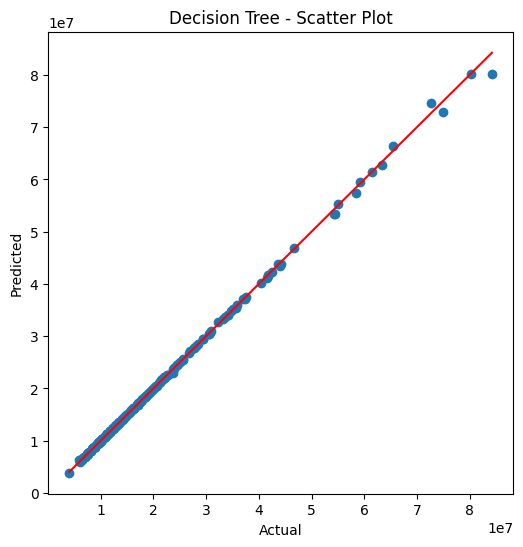

In [29]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, DT_predict)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree - Scatter Plot")

plt.show()

 K Neighbor Algorithm

In [30]:
knn_Model = KNeighborsRegressor(n_neighbors=7)
knn_Model.fit(x_train,y_train)
knn_predict=knn_Model.predict(x_test)
print(knn_predict)

[ 7001127.42857143  7372440.42857143 13562600.14285714 12510050.57142857
 19764387.85714286  9945446.85714286  6746982.         27789810.57142857
 22039237.28571429 13971536.          6926745.42857143  6665363.14285714
 20335944.85714286 28353808.71428571 14478844.14285714  9707158.
 12342491.28571429 10662570.28571429 11072981.28571429 18950692.71428571
 35845038.85714286 12213474.14285714 23735136.57142857 30540101.28571429
 33994255.42857143 22898582.14285714  8124834.71428571  8288235.85714286
  7001127.42857143 11204193.85714286 14652487.         21863629.42857143
 62283809.         30540101.28571429 19031172.57142857 13197727.28571429
 14799445.57142857 10893857.         16958493.85714286 12670701.85714286
 11792852.42857143 11251917.         11729290.42857143 22039237.28571429
 58796877.71428572 14247104.57142857 12213474.14285714 17618519.85714286
 16789058.         54527500.71428572  6386416.          8648781.28571429
 16306318.71428571 11156217.         11837883.         1278

In [31]:
print(knn_predict.shape)

(258,)


In [32]:
dataset=pd.DataFrame({'Actual':y_test, 'Predicted':knn_predict})
dataset

,Actual,Predicted
0,7007330,7.001127e+06
1,7349922,7.372440e+06
2,13565659,1.356260e+07
3,12496073,1.251005e+07
4,19762858,1.976439e+07
...,...,...
253,9347626,9.334425e+06
254,7576878,7.516602e+06
255,23727866,2.373514e+07
256,35100458,3.501686e+07


In [33]:

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, knn_predict))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, knn_predict))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test,knn_predict)))

Mean Absolute Error: 75416.89202657819
Mean Squared Error: 91285984895.43288
Root Mean Squared Error: 302135.70609153906


In [34]:
knn_result=knn_Model.score(x_test,y_test)*100

In [35]:
print("Accuracy: ",round(knn_result,2),'%')

Accuracy:  99.95 %


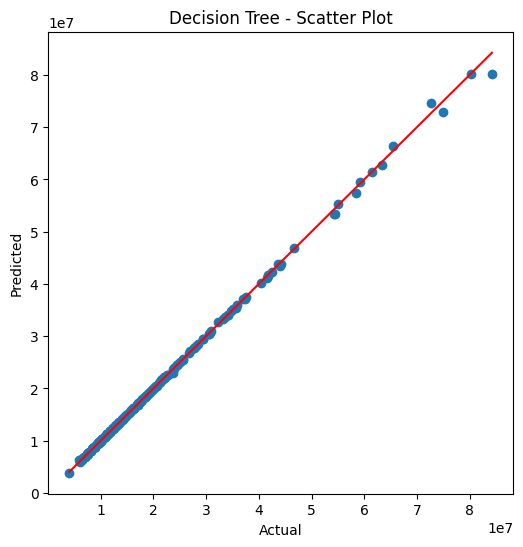

In [36]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, DT_predict)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree - Scatter Plot")

plt.show()

 Comparing accuracy

In [37]:
 
Model = ['RANDOM FOREST','DECISION TREE','K- NEIGHBOUR']
accuracy = [RF_result,DT_result,knn_result]

C:\Users\dixit\AppData\Local\Temp\ipykernel_11788\2739301789.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Model, y=accuracy, palette="viridis")


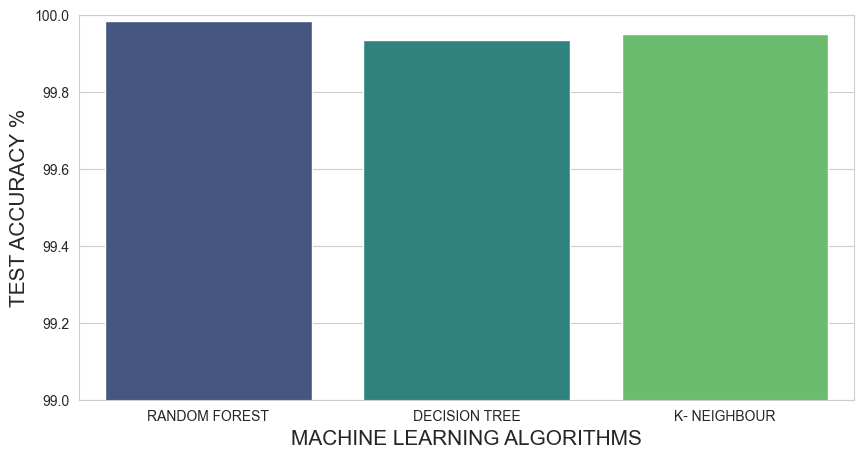

In [38]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))

plt.ylim(99,100)
plt.ylabel("TEST ACCURACY %", fontsize=15)
plt.xlabel("MACHINE LEARNING ALGORITHMS", fontsize=15)

sns.barplot(x=Model, y=accuracy, palette="viridis")   

plt.show()